In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def generate_synthetic_data(n_points=50, noise_std=0.1):
    """Generate synthetic 1D regression data"""
    X = torch.linspace(-3, 3, n_points).unsqueeze(-1)
    
    # True function: sinusoidal with varying amplitude
    y_true = torch.sin(X.squeeze()) + 0.3 * torch.sin(3 * X.squeeze()) 
    
    # Add noise
    y = y_true + noise_std * torch.randn(n_points)
    
    return X, y, y_true

def plot_results(gp, X_train, y_train, X_test, y_test_true=None):
    """Plot GP predictions with uncertainty"""

    # Make predictions
    pred_mean, pred_std, pred_samples = gp.predict(X_test, num_samples=200)

    # Convert all data to numpy arrays for consistent plotting
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().numpy()
        elif hasattr(x, 'numpy'):  # JAX arrays
            return np.array(x)
        else:
            return np.array(x)
    
    # Convert all tensors to numpy
    X_train = to_numpy(X_train)
    y_train = to_numpy(y_train)
    X_test = to_numpy(X_test)
    pred_mean = to_numpy(pred_mean)
    pred_std = to_numpy(pred_std)
    pred_samples = to_numpy(pred_samples)
    
    if y_test_true is not None:
        y_test_true = to_numpy(y_test_true)
    
    plt.figure(figsize=(12, 8))
    
    # Plot training data
    plt.scatter(X_train, y_train, c='red', s=50, 
                label='Training Data', zorder=3)
    
    # Plot true function if available
    if y_test_true is not None:
        plt.plot(X_test, y_test_true, 'g--', 
                linewidth=2, label='True Function')
    
    # Plot predictive mean
    plt.plot(X_test, pred_mean, 'b-', 
             linewidth=2, label='GP Mean')
    
    # Debug: Print std statistics
    print(f"pred_std min: {np.min(pred_std):.4f}, max: {np.max(pred_std):.4f}, mean: {np.mean(pred_std):.4f}")
    
    # Plot uncertainty bands
    plt.fill_between(X_test.squeeze(), 
                     (pred_mean - 2*pred_std),
                     (pred_mean + 2*pred_std),
                     alpha=0.3, color='blue', label='±2σ')
    
    # Plot some function samples
    for i in range(min(10, pred_samples.shape[0])):
        plt.plot(X_test, pred_samples[i], 
                'c-', alpha=0.1, linewidth=1)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Bayesian Gaussian Process Regression')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== PyTorch Version ===

1. Generating synthetic data...
Training data: 30 points
Test data: 100 points

2. Fitting Bayesian GP with NUTS...


Warmup:   0%|          | 0/1200 [00:00, ?it/s]

Sample: 100%|██████████| 1200/1200 [00:10, 110.51it/s, step size=3.55e-01, acc. prob=0.909]


MCMC completed with 800 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.761, std=0.121
variance    : mean=0.723, std=0.492
noise       : mean=0.015, std=0.006

3. Making predictions...
Numerical issue in sample 48, skipping...
Numerical issue in sample 57, skipping...
Numerical issue in sample 93, skipping...
Numerical issue in sample 96, skipping...
Numerical issue in sample 125, skipping...
Numerical issue in sample 131, skipping...
Numerical issue in sample 186, skipping...
Numerical issue in sample 187, skipping...
Prediction shape: torch.Size([100])
Number of function samples: 192

4. Plotting results...
Numerical issue in sample 18, skipping...
Numerical issue in sample 70, skipping...
Numerical issue in sample 71, skipping...
Numerical issue in sample 94, skipping...
Numerical issue in sample 125, skipping...
Numerical issue in sample 135, skipping...
Numerical issue in sample 155, skipping...
Numerical issue in sample 177, skipping...
N

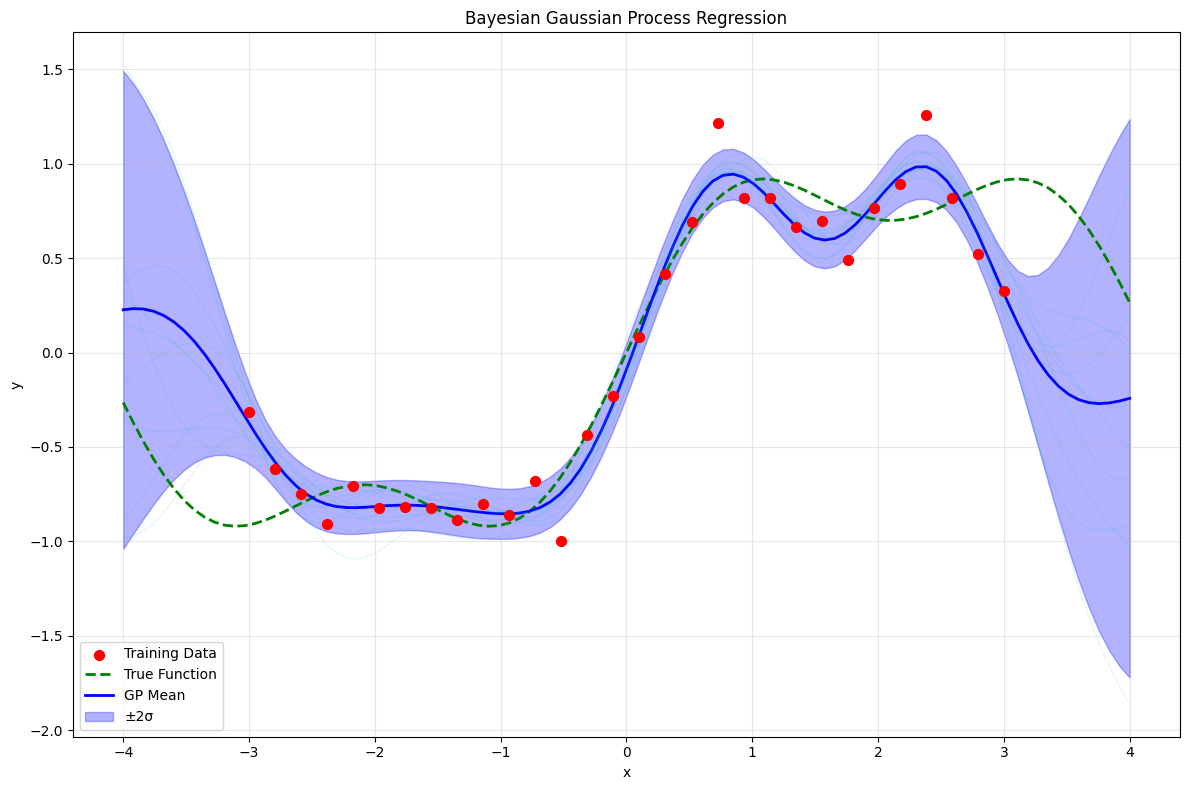

In [7]:
# PyTorch version
print("=== PyTorch Version ===")
from things.bgp import BayesianGP

# Generate synthetic data
print("\n1. Generating synthetic data...")
X_train, y_train, _ = generate_synthetic_data(n_points=30, noise_std=0.15)

# Create test points for prediction
X_test = torch.linspace(-4, 4, 100).unsqueeze(-1)
_, _, y_test_true = generate_synthetic_data(n_points=100, noise_std=0.0)

print(f"Training data: {X_train.shape[0]} points")
print(f"Test data: {X_test.shape[0]} points")

# Initialize and fit GP
print("\n2. Fitting Bayesian GP with NUTS...")
gp = BayesianGP(kernel='rbf')

# Fit with NUTS sampling
gp.fit(X_train, y_train, num_samples=800, warmup_steps=400)

# Make predictions
print("\n3. Making predictions...")
pred_mean, pred_std, pred_samples = gp.predict(X_test, num_samples=200)

print(f"Prediction shape: {pred_mean.shape}")
print(f"Number of function samples: {pred_samples.shape[0]}")

# Plot results
print("\n4. Plotting results...")
plot_results(gp, X_train, y_train, X_test, y_test_true)

print("\n" + "="*50)

=== JAX Version ===

1. Using same synthetic data...
Training data: 30 points
Test data: 100 points

2. Fitting Bayesian GP with NUTS...
torch.Size([30, 1]) torch.Size([30])


sample: 100%|██████████| 1200/1200 [00:01<00:00, 1075.51it/s, 15 steps of size 3.81e-01. acc. prob=0.89]



MCMC completed with 800 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.774, std=0.160
variance    : mean=0.726, std=0.516
noise       : mean=0.016, std=0.007

3. Making predictions...
Prediction shape: (100,)
Number of function samples: 200

4. Plotting results...
pred_std min: 0.0617, max: 0.7908, mean: 0.1677


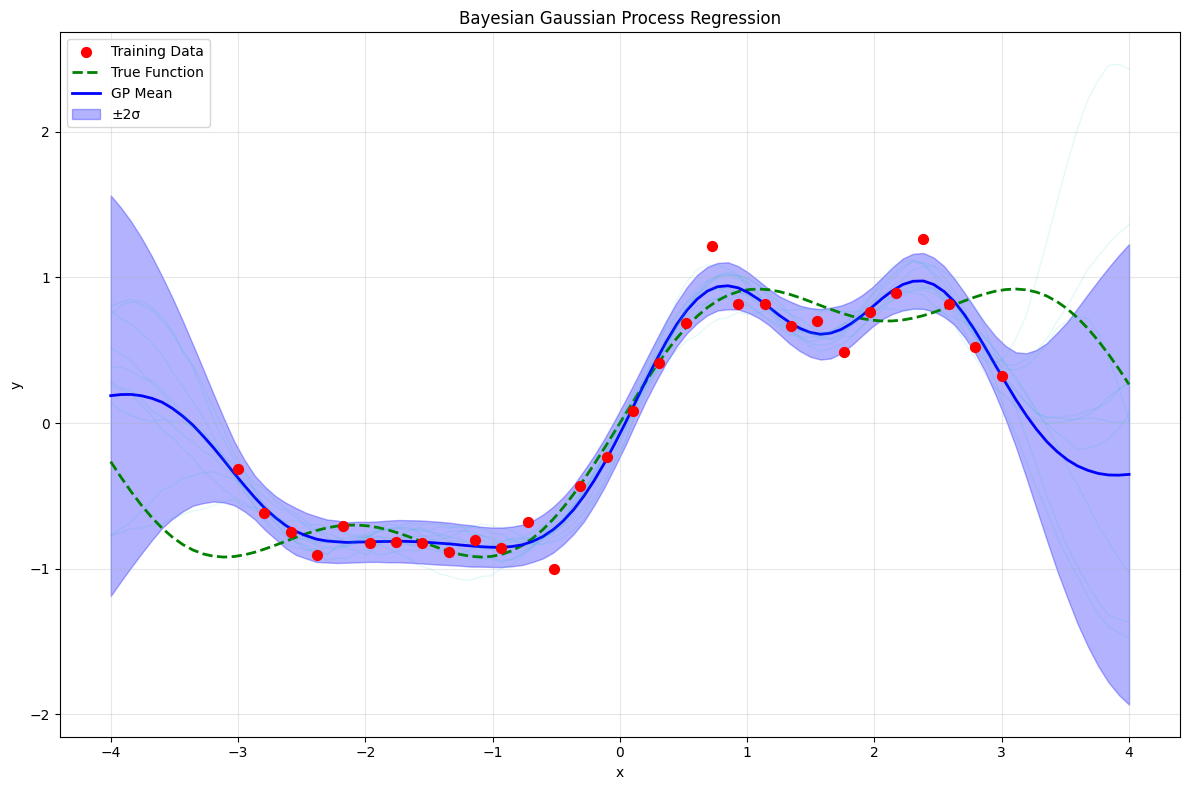

In [10]:
# JAX version  
print("=== JAX Version ===")
from things.bgp_jax import BayesianGP

# Generate synthetic data (reuse same data for fair comparison)
print("\n1. Using same synthetic data...")

print(f"Training data: {X_train.shape[0]} points")
print(f"Test data: {X_test.shape[0]} points")

# Initialize and fit GP
print("\n2. Fitting Bayesian GP with NUTS...")
gp_jax = BayesianGP(kernel='rbf', normalization=1e-4)

# Fit with NUTS sampling
print(X_train.shape, y_train.shape)
gp_jax.fit(X_train, y_train, num_samples=800, warmup_steps=400)

# Make predictions
print("\n3. Making predictions...")
pred_mean_jax, pred_std_jax, pred_samples_jax = gp_jax.predict(X_test, num_samples=200)

print(f"Prediction shape: {pred_mean_jax.shape}")
print(f"Number of function samples: {pred_samples_jax.shape[0]}")

# Plot results - NO manual conversion needed, let plot_results handle it
print("\n4. Plotting results...")
plot_results(gp_jax, X_train, y_train, X_test, y_test_true)


5. Hyperparameter posterior analysis:


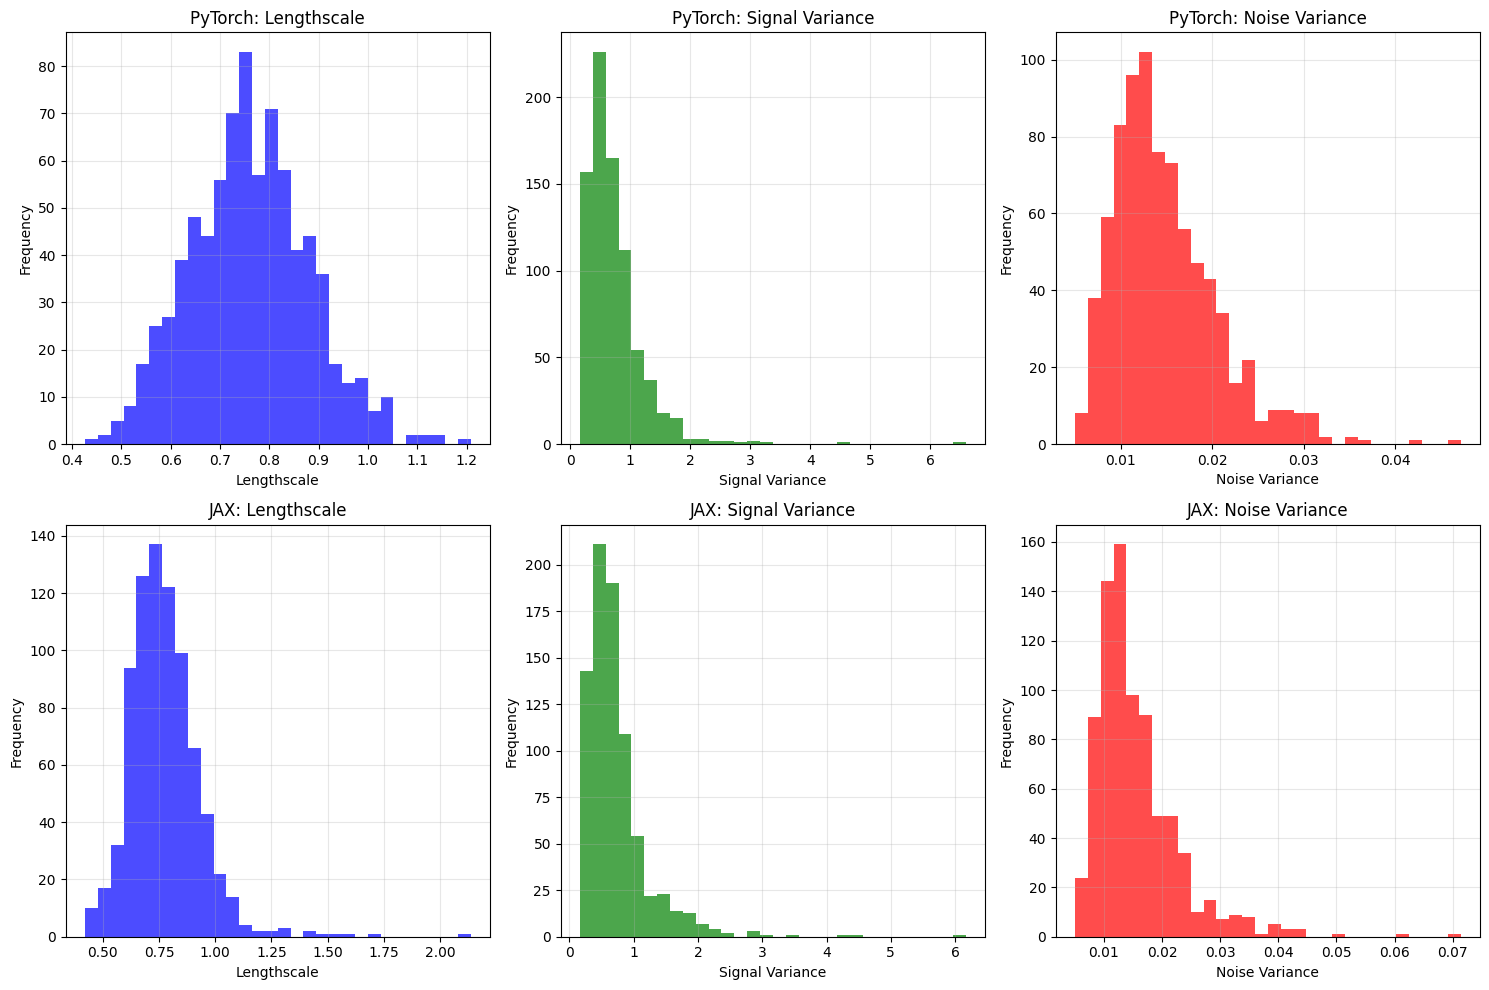


Bayesian GP analysis complete!


In [9]:
# Demonstrate hyperparameter posterior for both
print("\n5. Hyperparameter posterior analysis:")

# PyTorch version
lengthscales = gp.samples['lengthscale'].numpy()
variances = gp.samples['variance'].numpy()
noises = gp.samples['noise'].numpy()

# JAX version  
lengthscales_jax = np.array(gp_jax.samples['lengthscale'])
variances_jax = np.array(gp_jax.samples['variance'])
noises_jax = np.array(gp_jax.samples['noise'])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# PyTorch histograms
axes[0, 0].hist(lengthscales, bins=30, alpha=0.7, color='blue')
axes[0, 0].set_xlabel('Lengthscale')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PyTorch: Lengthscale')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(variances, bins=30, alpha=0.7, color='green')
axes[0, 1].set_xlabel('Signal Variance')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('PyTorch: Signal Variance')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(noises, bins=30, alpha=0.7, color='red')
axes[0, 2].set_xlabel('Noise Variance')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('PyTorch: Noise Variance')
axes[0, 2].grid(True, alpha=0.3)

# JAX histograms
axes[1, 0].hist(lengthscales_jax, bins=30, alpha=0.7, color='blue')
axes[1, 0].set_xlabel('Lengthscale')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('JAX: Lengthscale')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(variances_jax, bins=30, alpha=0.7, color='green')
axes[1, 1].set_xlabel('Signal Variance')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('JAX: Signal Variance')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(noises_jax, bins=30, alpha=0.7, color='red')
axes[1, 2].set_xlabel('Noise Variance')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('JAX: Noise Variance')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBayesian GP analysis complete!")